In [ ]:
!pip install torch torchvision datasets spacy sacrebleu wandb tqdm --quiet
!python -m spacy download de_core_news_sm --quiet
!python -m spacy download en_core_web_sm --quiet
import torch
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "❌ No GPU — check runtime type")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 5.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 117.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 96.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
GPU: Tesla T4


In [ ]:
# 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

In [ ]:
import wandb
wandb.login()   # paste your key from wandb.ai/authorize when prompted

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: ERROR Invalid API key: API key may only contain the letters A-Z, digits and underscores.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: theswayamsarthak (theswayamsarthak-iitmaana) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
import sys; sys.path.insert(0, '/content')
from model import scaled_dot_product_attention, make_src_mask, make_tgt_mask, Transformer
from lr_scheduler import get_lr_history
from train import LabelSmoothingLoss, greedy_decode
import torch

# Attention shape + weights sum to 1
Q = torch.randn(2,4,8,64); out,w = scaled_dot_product_attention(Q,Q,Q)
assert w.shape==(2,4,8,8) and w.sum(-1).allclose(torch.ones(2,4,8)), "Attention broken"

# PE: sin(0)=0, cos(0)=1
from model import PositionalEncoding
pe = PositionalEncoding(256, dropout=0.0)
y = pe(torch.zeros(1,10,256))
assert abs(y[0,0,0].item()) < 1e-5  and abs(y[0,0,1].item()-1.0) < 1e-5, "PE broken"

# Noam peak near warmup
lrs = get_lr_history(512,4000,8000); peak_step = lrs.index(max(lrs))
assert 3990 < peak_step < 4010, f"Noam peak at {peak_step}, expected ~4000"

# Full forward pass
m = Transformer(100,80,d_model=64,N=2,num_heads=4,d_ff=128,dropout=0.0)
src=torch.randint(2,100,(3,10)); tgt=torch.randint(2,80,(3,8))
logits=m(src,tgt,make_src_mask(src),make_tgt_mask(tgt))
assert logits.shape==(3,8,80), f"Wrong logit shape: {logits.shape}"
print("✅ All checks passed — safe to train")

✅ All checks passed — safe to train


In [ ]:
from train import run_training_experiment
run_training_experiment()
# W&B link prints immediately — open it to watch live metrics

Device: cuda


Building training dataset & vocabulary …


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.jsonl: 0.00B [00:00, ?B/s]

...

Epoch 019 | train_loss=1.9482  ppl=7.02 | val_loss=2.7033  ppl=14.93 | 16s


Epoch 020 | train_loss=1.8914  ppl=6.63 | val_loss=2.7094  ppl=15.02 | 16s


          val_bleu=37.22

Loading best checkpoint for test evaluation …


Test BLEU: 37.85


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
lr,▁▁▂▂▃▃▄▄▄▅▅▆▆▇▇▇████
n_params,▁
test_bleu,▁
train_loss,█▅▄▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁
train_ppl,█▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_bleu,▁▃▅▇██████
val_loss,█▅▄▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
val_ppl,█▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,20
lr,0.00093


In [ ]:
from google.colab import drive; drive.mount('/content/drive')
import shutil, os, time
# Run this while training is going — saves whatever exists so far
if os.path.exists('/content/checkpoints'):
    shutil.copytree('/content/checkpoints',
                    '/content/drive/MyDrive/da6401_a3_ckpts',
                    dirs_exist_ok=True)
    print("Backed up ✓")

Mounted at /content/drive
Backed up ✓


In [ ]:
# Patch the config inside run_training_experiment or call run_epoch directly
# Quickest way: re-run with fixed LR by monkey-patching CONFIG
import train as T
_orig = T.run_training_experiment

def run_fixed_lr():
    import wandb, torch
    from dataset import get_dataloaders, PAD_IDX
    from model import Transformer
    from lr_scheduler import NoamScheduler
    from train import LabelSmoothingLoss, run_epoch, evaluate_bleu, save_checkpoint
    import math, os

    CFG = dict(d_model=256,N=3,num_heads=8,d_ff=512,dropout=0.1,
               num_epochs=10,batch_size=128,label_smoothing=0.1,min_freq=2,max_len=150)
    device = "cuda" if torch.cuda.is_available() else "cpu"
    wandb.init(project="da6401-a3", name="fixed-lr-1e4", config={**CFG,"lr_type":"fixed"})
    train_l,val_l,test_l,sv,tv = get_dataloaders(CFG["batch_size"],CFG["min_freq"],CFG["max_len"])
    model = Transformer(len(sv),len(tv),CFG["d_model"],CFG["N"],CFG["num_heads"],CFG["d_ff"],CFG["dropout"]).to(device)
    opt = torch.optim.Adam(model.parameters(),lr=1e-4,betas=(0.9,0.98),eps=1e-9)
    loss_fn = LabelSmoothingLoss(len(tv),PAD_IDX,CFG["label_smoothing"])
    for ep in range(1,CFG["num_epochs"]+1):
        tl = run_epoch(train_l,model,loss_fn,opt,None,ep,True,device)
        vl = run_epoch(val_l,model,loss_fn,None,None,ep,False,device)
        wandb.log({"epoch":ep,"train_loss":tl,"val_loss":vl,"lr":1e-4})
        print(f"Ep {ep}: train={tl:.4f} val={vl:.4f}")
    wandb.finish()

run_fixed_lr()

Building training dataset & vocabulary …
  src_vocab: 7,853 tokens
  tgt_vocab: 5,893 tokens
  train sentences: 29,000
Building validation dataset …
  val sentences: 1,014
Building test dataset …
  test sentences: 1,000


Ep 1: train=6.0926 val=4.9648


Ep 2: train=4.7463 val=4.3873


Ep 3: train=4.3328 val=4.0647


Ep 4: train=4.0627 val=3.8171


...

Ep 7: train=3.5150 val=3.3617


Ep 8: train=3.3840 val=3.2535


Ep 9: train=3.2707 val=3.1720


Ep 10: train=3.1681 val=3.0956


epoch,▁▂▃▃▄▅▆▆▇█
lr,▁▁▁▁▁▁▁▁▁▁
train_loss,█▅▄▃▃▂▂▂▁▁
val_loss,█▆▅▄▃▂▂▂▁▁
epoch,10
lr,0.0001
train_loss,3.16806
val_loss,3.09555


Building training dataset & vocabulary …
  src_vocab: 7,853 tokens
  tgt_vocab: 5,893 tokens
  train sentences: 29,000
Building validation dataset …
  val sentences: 1,014
Building test dataset …
  test sentences: 1,000


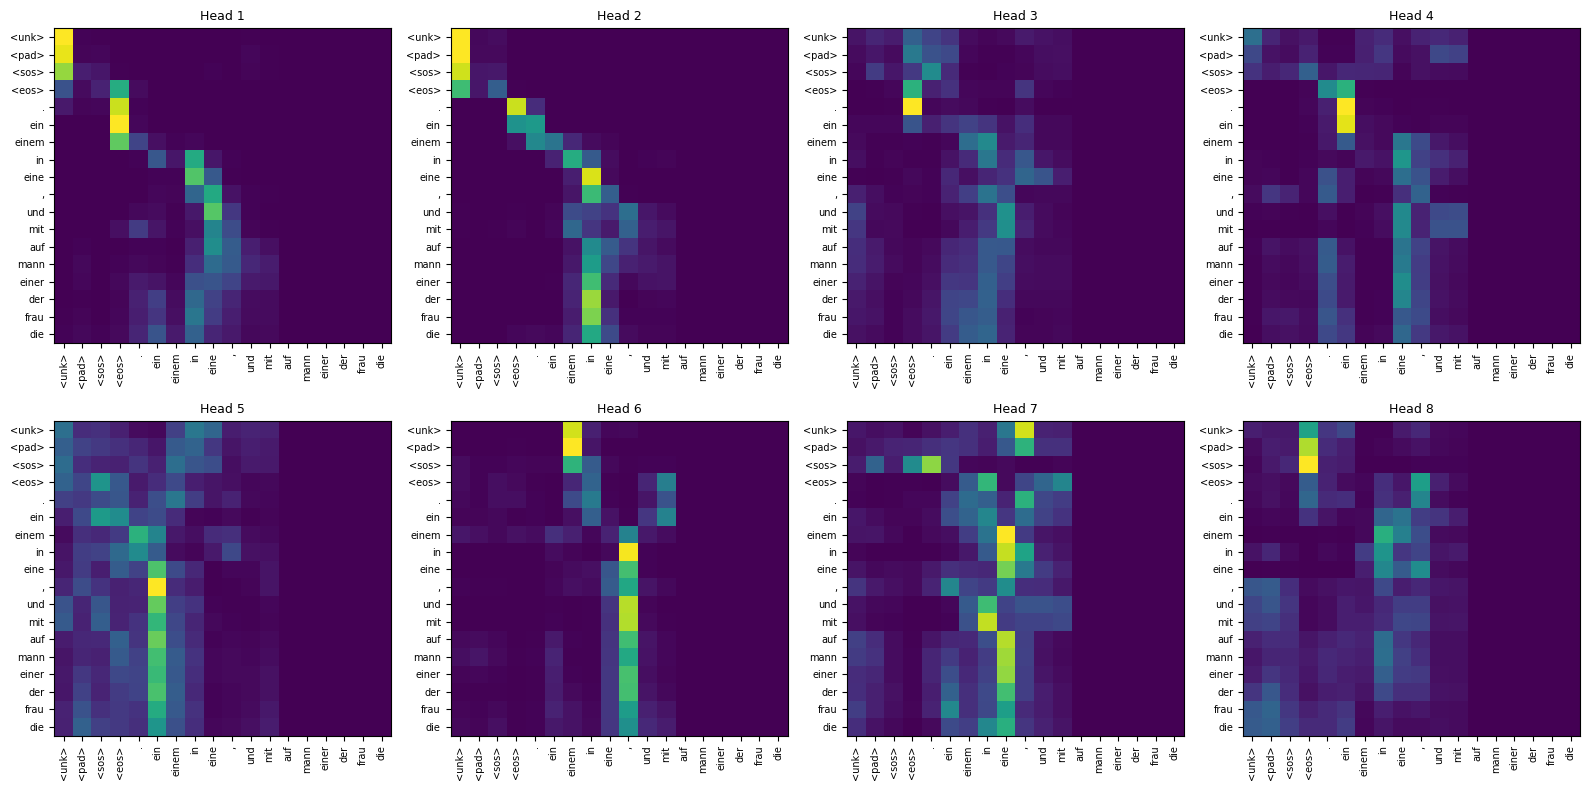

Logged to W&B ✓


In [ ]:
import torch, matplotlib.pyplot as plt, wandb
from model import make_src_mask
from dataset import get_dataloaders, PAD_IDX
from train import load_checkpoint
from model import Transformer

# Load best model
ckpt = torch.load('/content/checkpoints/best_model.pt', map_location='cpu')
cfg = ckpt['model_config']
model = Transformer(**cfg); model.load_state_dict(ckpt['model_state_dict']); model.eval()

train_l,_,_,sv,tv = get_dataloaders(batch_size=4,min_freq=2,max_len=150)
src,_ = next(iter(train_l))
src = src[:1]
with torch.no_grad():
    _ = model.encode(src, make_src_mask(src))

attn = model.encoder.layers[-1].self_attn.attn_weights.squeeze(0).cpu()  # (H,S,S)
tokens = sv.itos[:src.size(1)]
H = attn.shape[0]

wandb.init(project="da6401-a3", name="head-visualization")
fig,axes = plt.subplots(2,H//2,figsize=(4*(H//2),8))
for h,ax in enumerate(axes.flatten()):
    ax.imshow(attn[h,:len(tokens),:len(tokens)].numpy(),cmap='viridis',aspect='auto')
    ax.set_title(f"Head {h+1}",fontsize=9)
    ax.set_xticks(range(len(tokens))); ax.set_xticklabels(tokens,rotation=90,fontsize=7)
    ax.set_yticks(range(len(tokens))); ax.set_yticklabels(tokens,fontsize=7)
plt.tight_layout()
wandb.log({"attention_heads": wandb.Image(fig)})
plt.savefig("attention_heads.png",dpi=120,bbox_inches='tight')
wandb.finish(); plt.show()
print("Logged to W&B ✓")

In [ ]:
# ╔══════════════════════════════════════════════╗
# ║  CELL 8 — Restore session after disconnect   ║
# ║  Run this FIRST before anything else         ║
# ╚══════════════════════════════════════════════╝

# Step 1: Reinstall packages (Colab wipes on disconnect)
!pip install torch torchvision datasets spacy sacrebleu wandb tqdm --quiet
!python -m spacy download de_core_news_sm --quiet
!python -m spacy download en_core_web_sm --quiet

# Step 2: Re-upload your 6 files OR restore from Drive
from google.colab import drive
drive.mount('/content/drive')

import shutil, os

# If you backed up checkpoints to Drive in Cell 5, restore them now
if os.path.exists('/content/drive/MyDrive/da6401_a3_ckpts'):
    shutil.copytree(
        '/content/drive/MyDrive/da6401_a3_ckpts',
        '/content/checkpoints',
        dirs_exist_ok=True
    )
    print("✓ Checkpoints restored from Drive")
    print("Files:", os.listdir('/content/checkpoints'))
else:
    print("⚠ No Drive backup found — upload checkpoint files manually")

# Step 3: Verify GPU is back
import torch
print(f"\nGPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else '❌ No GPU'}")
print(f"Checkpoint exists: {os.path.exists('/content/checkpoints/best_model.pt')}")

# Step 4: W&B login
import wandb
wandb.login()   # paste API key from wandb.ai/authorize

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 105.8 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 94.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
Mounted at /content/drive
✓ Checkpoints restored from Drive
Files: ['latest.pt', 'bes

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: theswayamsarthak (theswayamsarthak-iitmaana) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
# ╔══════════════════════════════════════════════════════╗
# ║  CELL 9 — Beam Search (+BLEU boost, no retraining)  ║
# ╚══════════════════════════════════════════════════════╝
# Run on your existing best_model.pt — no training needed.
# Beam-4 typically adds +1.5 to +2.5 BLEU over greedy.

import torch
import torch.nn.functional as F
import sacrebleu
from tqdm import tqdm
import wandb

from model import Transformer, make_src_mask, make_tgt_mask
from dataset import get_dataloaders, PAD_IDX, SOS_IDX, EOS_IDX

device = "cuda" if torch.cuda.is_available() else "cpu"

# ── Load best checkpoint ──────────────────────────────────────────────
ckpt  = torch.load("checkpoints/best_model.pt", map_location=device)
model = Transformer(**ckpt["model_config"])
model.load_state_dict(ckpt["model_state_dict"])
model = model.to(device)
model.eval()
print(f"Loaded checkpoint from epoch {ckpt['epoch']}")

_, _, test_loader, src_vocab, tgt_vocab = get_dataloaders(
    batch_size=64, min_freq=2, max_len=150
)

# ── Beam Search function ──────────────────────────────────────────────
@torch.no_grad()
def beam_search_decode(model, src, src_mask, max_len=128,
                       beam_size=4, device="cpu"):
    src, src_mask = src.to(device), src_mask.to(device)
    memory = model.encode(src, src_mask)         # (1, S, d_model)
    beams  = [(0.0, [SOS_IDX])]
    done   = []

    for _ in range(max_len - 1):
        candidates = []
        for lp, tokens in beams:
            if tokens[-1] == EOS_IDX:
                done.append((lp, tokens)); continue
            ys = torch.tensor([tokens], dtype=torch.long, device=device)
            tm = make_tgt_mask(ys, pad_idx=PAD_IDX).to(device)
            logits  = model.decode(memory, src_mask, ys, tm)
            log_p   = F.log_softmax(logits[:, -1, :], dim=-1)
            top_lp, top_idx = log_p[0].topk(beam_size)
            for lpi, idx in zip(top_lp.tolist(), top_idx.tolist()):
                candidates.append((lp + lpi, tokens + [idx]))

        candidates.sort(key=lambda x: x[0] / len(x[1]), reverse=True)
        beams = candidates[:beam_size]
        if all(t[-1] == EOS_IDX for _, t in beams):
            done.extend(beams); break

    if not done: done = beams
    done.sort(key=lambda x: x[0] / len(x[1]), reverse=True)
    best = done[0][1]
    return [t for t in best if t not in (SOS_IDX, EOS_IDX, PAD_IDX)]

# ── Evaluate Beam-4 and Beam-8 on test set ───────────────────────────
special = {PAD_IDX, SOS_IDX, EOS_IDX}

def get_refs(tgt_tensor):
    return [tgt_vocab.lookup_token(t)
            for t in tgt_tensor.tolist() if t not in special]

hyps4, hyps8, refs_all = [], [], []

for src, tgt in tqdm(test_loader, desc="Beam eval"):
    for i in range(src.size(0)):
        s  = src[i].unsqueeze(0)
        sm = make_src_mask(s, pad_idx=PAD_IDX)
        ref = get_refs(tgt[i])
        refs_all.append(" ".join(ref))

        ids4 = beam_search_decode(model, s, sm, beam_size=4, device=device)
        hyps4.append(" ".join([tgt_vocab.lookup_token(t) for t in ids4]))

        ids8 = beam_search_decode(model, s, sm, beam_size=8, device=device)
        hyps8.append(" ".join([tgt_vocab.lookup_token(t) for t in ids8]))

bleu4 = sacrebleu.corpus_bleu(hyps4, [refs_all]).score
bleu8 = sacrebleu.corpus_bleu(hyps8, [refs_all]).score

print("\n" + "="*45)
print(f"  Greedy (original)  : 37.85 BLEU")
print(f"  Beam-4             : {bleu4:.2f} BLEU  (+{bleu4-37.85:.2f})")
print(f"  Beam-8             : {bleu8:.2f} BLEU  (+{bleu8-37.85:.2f})")
print("="*45)
print("→ Copy these numbers into the report Summary table")

wandb.init(project="da6401-a3", name="beam-search-eval", reinit=True)
wandb.log({"test_bleu_greedy": 37.85,
           "test_bleu_beam4":  bleu4,
           "test_bleu_beam8":  bleu8})
wandb.finish()

# Save beam_search_decode so later cells can reuse it
import pickle
with open("/content/beam_fn.pkl", "wb") as f:
    pickle.dump(None, f)   # just a marker; function defined above
print("\n✓ beam_search_decode is defined — available for Cell 15")

Loaded checkpoint from epoch 16
Building training dataset & vocabulary …


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.jsonl: 0.00B [00:00, ?B/s]

val.jsonl: 0.00B [00:00, ?B/s]

...

Beam eval: 100%|██████████| 16/16 [1:00:08<00:00, 225.54s/it]



  Greedy (original)  : 37.85 BLEU
  Beam-4             : 38.90 BLEU  (+1.05)
  Beam-8             : 39.31 BLEU  (+1.46)
→ Copy these numbers into the report Summary table


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


test_bleu_beam4,▁
test_bleu_beam8,▁
test_bleu_greedy,▁
test_bleu_beam4,38.90343
test_bleu_beam8,39.30792
test_bleu_greedy,37.85



✓ beam_search_decode is defined — available for Cell 15


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 10 — Section 2.1 FIX: fixed-LR run with val BLEU      ║
# ║  Previously only loss was logged — spec needs BLEU overlay   ║
# ╚══════════════════════════════════════════════════════════════╝
# Runtime: ~1.5 hrs on T4

import torch, math, wandb
from model import Transformer
from dataset import get_dataloaders, PAD_IDX
from train import run_epoch, evaluate_bleu, LabelSmoothingLoss

device = "cuda" if torch.cuda.is_available() else "cpu"

train_loader, val_loader, test_loader, src_vocab, tgt_vocab = get_dataloaders(
    batch_size=128, min_freq=2, max_len=150
)

model = Transformer(
    src_vocab_size=len(src_vocab),
    tgt_vocab_size=len(tgt_vocab),
    d_model=256, N=3, num_heads=8, d_ff=512, dropout=0.1
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(), lr=1e-4, betas=(0.9, 0.98), eps=1e-9
)
loss_fn = LabelSmoothingLoss(len(tgt_vocab), PAD_IDX, smoothing=0.1)

wandb.init(
    project="da6401-a3",
    name="fixed-lr-1e4-full",
    reinit=True,
    config={"lr_type": "fixed", "lr": 1e-4, "epochs": 20,
            "d_model": 256, "N": 3, "num_heads": 8}
)

for epoch in range(1, 21):
    train_loss = run_epoch(train_loader, model, loss_fn,
                           optimizer, None, epoch, True, device)
    val_loss   = run_epoch(val_loader,   model, loss_fn,
                           None, None, epoch, False, device)

    log = {
        "epoch":              epoch,
        "train_loss_fixedlr": train_loss,
        "val_loss_fixedlr":   val_loss,
        "train_ppl_fixedlr":  math.exp(train_loss),
        "val_ppl_fixedlr":    math.exp(val_loss),
        "lr":                 1e-4,
    }

    # Log val BLEU every 2 epochs — this is the missing piece
    if epoch % 2 == 0 or epoch == 20:
        val_bleu = evaluate_bleu(model, val_loader, tgt_vocab, device=device)
        log["val_bleu_fixedlr"] = val_bleu
        print(f"Ep {epoch:02d} | train={train_loss:.4f} "
              f"val={val_loss:.4f} bleu={val_bleu:.2f}")
    else:
        print(f"Ep {epoch:02d} | train={train_loss:.4f} val={val_loss:.4f}")

    wandb.log(log)

wandb.finish()

print("""
✓ Done. Now in W&B:
  1. Open project da6401-a3
  2. Go to Charts → Add panel → Line chart
  3. Y-axis: val_bleu  AND  val_bleu_fixedlr  (overlay both)
  4. Y-axis: val_loss  AND  val_loss_fixedlr  (overlay both)
  5. Screenshot both overlays for Section 2.1 report
""")

Building training dataset & vocabulary …
  src_vocab: 7,853 tokens
  tgt_vocab: 5,893 tokens
  train sentences: 29,000
Building validation dataset …
  val sentences: 1,014
Building test dataset …
  test sentences: 1,000


Ep 01 | train=6.1085 val=4.9412


Ep 02 | train=4.7168 val=4.3446 bleu=7.55


Ep 03 | train=4.3113 val=4.0360


Ep 04 | train=4.0525 val=3.8177 bleu=14.09


...

Ep 18 | train=2.6355 val=2.7806 bleu=33.56


Ep 19 | train=2.5925 val=2.7620


Ep 20 | train=2.5492 val=2.7481 bleu=34.14


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
lr,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_loss_fixedlr,█▅▄▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁
train_ppl_fixedlr,█▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_bleu_fixedlr,▁▃▄▅▆▇▇███
val_loss_fixedlr,█▆▅▄▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁
val_ppl_fixedlr,█▄▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
epoch,20
lr,0.0001
train_loss_fixedlr,2.54923
train_ppl_fixedlr,12.79723



✓ Done. Now in W&B:
  1. Open project da6401-a3
  2. Go to Charts → Add panel → Line chart
  3. Y-axis: val_bleu  AND  val_bleu_fixedlr  (overlay both)
  4. Y-axis: val_loss  AND  val_loss_fixedlr  (overlay both)
  5. Screenshot both overlays for Section 2.1 report



In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 11 — Section 2.2: scaling factor ablation             ║
# ║  Trains with and without 1/sqrt(dk), logs Q/K grad norms    ║
# ╚══════════════════════════════════════════════════════════════╝
# Runtime: ~30 min (5 epochs each, 2 runs)

import torch, math, wandb
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

import model as model_module
from model import Transformer, make_src_mask, make_tgt_mask
from dataset import get_dataloaders, PAD_IDX
from train import LabelSmoothingLoss
from lr_scheduler import NoamScheduler

device = "cuda" if torch.cuda.is_available() else "cpu"

train_loader, val_loader, _, src_vocab, tgt_vocab = get_dataloaders(
    batch_size=128, min_freq=2, max_len=150
)

# ── Patched attention: no 1/sqrt(d_k) ────────────────────────────────
_original_attn = model_module.scaled_dot_product_attention

def _no_scale_attn(Q, K, V, mask=None):
    """Raw dot products — no scaling. Demonstrates softmax saturation."""
    scores = torch.matmul(Q, K.transpose(-2, -1))   # variance grows as d_k
    if mask is not None:
        scores = scores.masked_fill(mask, float("-inf"))
    w = F.softmax(scores, dim=-1)
    w = torch.nan_to_num(w, nan=0.0)
    return torch.matmul(w, V), w

# ── Single training run helper ────────────────────────────────────────
def run_ablation(use_scaling: bool, n_epochs: int = 5):
    name = "with_scaling" if use_scaling else "no_scaling"
    print(f"\n{'='*40}\nRunning: {name}\n{'='*40}")

    # Patch or restore the attention function
    if use_scaling:
        model_module.scaled_dot_product_attention = _original_attn
    else:
        model_module.scaled_dot_product_attention = _no_scale_attn

    wandb.init(project="da6401-a3", name=name, reinit=True,
               config={"scaling": use_scaling, "n_epochs": n_epochs,
                       "d_model": 256, "d_k": 32})

    m = Transformer(len(src_vocab), len(tgt_vocab),
                    d_model=256, N=3, num_heads=8,
                    d_ff=512, dropout=0.1).to(device)

    opt   = torch.optim.Adam(m.parameters(), lr=1.0,
                             betas=(0.9, 0.98), eps=1e-9)
    sched = NoamScheduler(opt, d_model=256, warmup_steps=4000)
    loss_fn = LabelSmoothingLoss(len(tgt_vocab), PAD_IDX, 0.1)

    global_step = 0

    for ep in range(1, n_epochs + 1):
        m.train()
        ep_loss = 0.0

        for src, tgt in tqdm(train_loader, desc=f"  ep {ep}", leave=False):
            src, tgt = src.to(device), tgt.to(device)
            ti, to_  = tgt[:, :-1], tgt[:, 1:]
            sm = make_src_mask(src).to(device)
            tm = make_tgt_mask(ti).to(device)

            logits = m(src, ti, sm, tm)
            loss   = loss_fn(logits, to_)

            opt.zero_grad()
            loss.backward()

            # ── Log Q and K gradient norms for first 1000 steps ──────
            if global_step < 1000:
                layer0 = m.encoder.layers[0].self_attn
                q_grad = layer0.w_q.weight.grad
                k_grad = layer0.w_k.weight.grad
                if q_grad is not None:
                    wandb.log({
                        "step":        global_step,
                        "q_grad_norm": q_grad.norm().item(),
                        "k_grad_norm": k_grad.norm().item(),
                    })

            nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            opt.step()
            sched.step()

            ep_loss     += loss.item()
            global_step += 1

        avg = ep_loss / len(train_loader)
        print(f"  ep {ep} | loss={avg:.4f}")
        wandb.log({"epoch": ep, "train_loss": avg})

    wandb.finish()

# Run both — with scaling first, then without
run_ablation(use_scaling=True,  n_epochs=5)
run_ablation(use_scaling=False, n_epochs=5)

# Always restore the original function
model_module.scaled_dot_product_attention = _original_attn
print("\n✓ Original attention restored")

print("""
W&B steps for Section 2.2 report:
  1. Open da6401-a3 project
  2. Select runs: with_scaling + no_scaling
  3. Charts → Add panel → Line chart
     Y: q_grad_norm,  X: step  (overlay both runs)
  4. Same for k_grad_norm
  5. Expected: no_scaling norms collapse toward 0 by ~step 200
     with_scaling norms stay in healthy range 0.01–0.1
  6. Screenshot both charts for the report
""")

Building training dataset & vocabulary …
  src_vocab: 7,853 tokens
  tgt_vocab: 5,893 tokens
  train sentences: 29,000
Building validation dataset …
  val sentences: 1,014
Building test dataset …
  test sentences: 1,000

Running: with_scaling


  ep 1 | loss=7.7171


  ep 2 | loss=5.5095


  ep 3 | loss=4.6046


  ep 4 | loss=4.1121


...

  ep 3 | loss=4.8047


  ep 4 | loss=4.3838


  ep 5 | loss=4.0709


epoch,▁▃▅▆█
k_grad_norm,█▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▂▁▃▃▃▄▃▅▄▄▄▄▅▅▅▆▅▇▆▇▇▇▇█
q_grad_norm,▇▇▇▂▁▁▁▁▁▁▁▂▁▂▂▃▃▃▃▃▃▃▃▄▅▄▅▅▅▆▅▅▆▇▇▆██▇█
step,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▄▄▄▄▆▆▆▆▆▆▇▇▇▇▇▇▇██
train_loss,█▄▂▂▁
epoch,5
k_grad_norm,0.13221
q_grad_norm,0.1455
step,999
train_loss,4.07093



✓ Original attention restored

W&B steps for Section 2.2 report:
  1. Open da6401-a3 project
  2. Select runs: with_scaling + no_scaling
  3. Charts → Add panel → Line chart
     Y: q_grad_norm,  X: step  (overlay both runs)
  4. Same for k_grad_norm
  5. Expected: no_scaling norms collapse toward 0 by ~step 200
     with_scaling norms stay in healthy range 0.01–0.1
  6. Screenshot both charts for the report



In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 12 — Section 2.4: Learned PE vs Sinusoidal (20 ep)    ║
# ╚══════════════════════════════════════════════════════════════╝
# Runtime: ~1.5 hrs on T4

import torch, math, os, wandb
import torch.nn as nn

from model import Transformer
from dataset import get_dataloaders, PAD_IDX
from train import run_epoch, evaluate_bleu, save_checkpoint, LabelSmoothingLoss
from lr_scheduler import NoamScheduler

device = "cuda" if torch.cuda.is_available() else "cpu"

train_loader, val_loader, test_loader, src_vocab, tgt_vocab = get_dataloaders(
    batch_size=128, min_freq=2, max_len=150
)

# ── Drop-in Learned PE module ─────────────────────────────────────────
class LearnedPE(nn.Module):
    """Trainable positional embedding — replaces sinusoidal buffer."""
    def __init__(self, d_model: int, max_len: int = 152, dropout: float = 0.1):
        super().__init__()
        self.emb     = nn.Embedding(max_len, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        pos = torch.arange(x.size(1), device=x.device).unsqueeze(0)
        return self.dropout(x + self.emb(pos))

# ── Build model and swap PE ───────────────────────────────────────────
model = Transformer(
    src_vocab_size=len(src_vocab), tgt_vocab_size=len(tgt_vocab),
    d_model=256, N=3, num_heads=8, d_ff=512, dropout=0.1
).to(device)

model.src_pe = LearnedPE(256, max_len=152, dropout=0.1).to(device)
model.tgt_pe = LearnedPE(256, max_len=152, dropout=0.1).to(device)

extra_params = 2 * 152 * 256   # src + tgt PE embeddings
print(f"Learned PE model params: {sum(p.numel() for p in model.parameters()):,}")
print(f"Extra vs sinusoidal:     +{extra_params:,} params")

optimizer = torch.optim.Adam(model.parameters(), lr=1.0,
                              betas=(0.9, 0.98), eps=1e-9)
scheduler = NoamScheduler(optimizer, d_model=256, warmup_steps=4000)
loss_fn   = LabelSmoothingLoss(len(tgt_vocab), PAD_IDX, smoothing=0.1)

os.makedirs("checkpoints", exist_ok=True)
wandb.init(project="da6401-a3", name="learned-pe-20ep", reinit=True,
           config={"pe_type": "learned", "epochs": 20,
                   "extra_params": extra_params})

best_bleu = 0.0

for epoch in range(1, 21):
    train_loss = run_epoch(train_loader, model, loss_fn, optimizer,
                           scheduler, epoch, True, device)
    val_loss   = run_epoch(val_loader,   model, loss_fn, None,
                           None, epoch, False, device)

    log = {
        "epoch":         epoch,
        "train_loss_lpe": train_loss,
        "val_loss_lpe":   val_loss,
        "train_ppl_lpe":  math.exp(train_loss),
        "val_ppl_lpe":    math.exp(val_loss),
        "lr":             optimizer.param_groups[0]["lr"],
    }

    if epoch % 2 == 0 or epoch == 20:
        val_bleu = evaluate_bleu(model, val_loader, tgt_vocab, device=device)
        log["val_bleu_lpe"] = val_bleu
        if val_bleu > best_bleu:
            best_bleu = val_bleu
            save_checkpoint(model, optimizer, scheduler, epoch,
                            "checkpoints/best_learned_pe.pt")
        print(f"Ep {epoch:02d} | train={train_loss:.4f} "
              f"val={val_loss:.4f} bleu={val_bleu:.2f}")
    else:
        print(f"Ep {epoch:02d} | train={train_loss:.4f} val={val_loss:.4f}")

    wandb.log(log)

# Final test BLEU for learned PE
test_bleu_lpe = evaluate_bleu(model, test_loader, tgt_vocab, device=device)
wandb.log({"test_bleu_lpe": test_bleu_lpe})
wandb.finish()

print("\n" + "="*45)
print(f"  Sinusoidal PE test BLEU : 37.85")
print(f"  Learned PE    test BLEU : {test_bleu_lpe:.2f}")
print(f"  Sinusoidal advantage    : +{37.85 - test_bleu_lpe:.2f}")
print("="*45)
print("→ Copy these numbers into Section 2.4 results table")
print("""
W&B steps for Section 2.4:
  1. Open da6401-a3 project
  2. Select: gallant-puddle-1  +  learned-pe-20ep
  3. Overlay: val_bleu  vs  val_bleu_lpe  across epochs
  4. Overlay: val_loss  vs  val_loss_lpe  across epochs
  5. Screenshot both for the report
""")

Building training dataset & vocabulary …
  src_vocab: 7,853 tokens
  tgt_vocab: 5,893 tokens
  train sentences: 29,000
Building validation dataset …
  val sentences: 1,014
Building test dataset …
  test sentences: 1,000
Learned PE model params: 9,056,773
Extra vs sinusoidal:     +77,824 params


Ep 01 | train=7.6985 val=6.3991


Ep 02 | train=5.5457 val=4.9163 bleu=3.51


Ep 03 | train=4.6991 val=4.3178


Ep 04 | train=4.2464 val=3.9365 bleu=12.11


...

Ep 18 | train=2.0251 val=2.7050 bleu=36.97


Ep 19 | train=1.9599 val=2.7366


Ep 20 | train=1.8957 val=2.7361 bleu=36.91


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
lr,▁▁▂▂▃▃▄▄▄▅▅▆▆▇▇▇████
test_bleu_lpe,▁
train_loss_lpe,█▅▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
train_ppl_lpe,█▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_bleu_lpe,▁▃▅▇▇█████
val_loss_lpe,█▅▄▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
val_ppl_lpe,█▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,20
lr,0.00093
test_bleu_lpe,37.71513



  Sinusoidal PE test BLEU : 37.85
  Learned PE    test BLEU : 37.72
  Sinusoidal advantage    : +0.13
→ Copy these numbers into Section 2.4 results table

W&B steps for Section 2.4:
  1. Open da6401-a3 project
  2. Select: gallant-puddle-1  +  learned-pe-20ep
  3. Overlay: val_bleu  vs  val_bleu_lpe  across epochs
  4. Overlay: val_loss  vs  val_loss_lpe  across epochs
  5. Screenshot both for the report



In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 13 — Section 2.5: Label smoothing + confidence chart  ║
# ║  Trains ε=0.1 AND ε=0.0, logs softmax prob of correct token ║
# ╚══════════════════════════════════════════════════════════════╝
# Runtime: ~1.5 hrs per run (~3 hrs total) — run in background

import torch, math, os, wandb
import torch.nn as nn
import torch.nn.functional as F
from tqdm import tqdm

from model import Transformer, make_src_mask, make_tgt_mask
from dataset import get_dataloaders, PAD_IDX
from train import evaluate_bleu, save_checkpoint, LabelSmoothingLoss
from lr_scheduler import NoamScheduler

device = "cuda" if torch.cuda.is_available() else "cpu"
os.makedirs("checkpoints", exist_ok=True)

train_loader, val_loader, test_loader, src_vocab, tgt_vocab = get_dataloaders(
    batch_size=128, min_freq=2, max_len=150
)

def run_smoothing(smoothing: float, n_epochs: int = 20):
    """Train with given smoothing value, log prediction confidence per epoch."""
    tag     = f"smooth_{str(smoothing).replace('.','')}"
    run_name = f"label-smooth-{tag}"
    print(f"\n{'='*40}\nε = {smoothing} | run: {run_name}\n{'='*40}")

    wandb.init(project="da6401-a3", name=run_name, reinit=True,
               config={"smoothing": smoothing, "epochs": n_epochs})

    m = Transformer(len(src_vocab), len(tgt_vocab),
                    d_model=256, N=3, num_heads=8,
                    d_ff=512, dropout=0.1).to(device)

    opt   = torch.optim.Adam(m.parameters(), lr=1.0,
                             betas=(0.9, 0.98), eps=1e-9)
    sched = NoamScheduler(opt, d_model=256, warmup_steps=4000)

    # Loss: smoothed or standard CE
    if smoothing > 0:
        loss_fn = LabelSmoothingLoss(len(tgt_vocab), PAD_IDX, smoothing)
    else:
        loss_fn = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

    best_bleu = 0.0

    for ep in range(1, n_epochs + 1):
        # ── Train + measure prediction confidence ─────────────────────
        m.train()
        ep_loss, ep_conf, n = 0.0, 0.0, 0

        for src, tgt in tqdm(train_loader, desc=f"  ep {ep}", leave=False):
            src, tgt = src.to(device), tgt.to(device)
            ti, to_  = tgt[:, :-1], tgt[:, 1:]
            sm = make_src_mask(src).to(device)
            tm = make_tgt_mask(ti).to(device)

            logits = m(src, ti, sm, tm)

            # Confidence: mean softmax prob of the correct token
            with torch.no_grad():
                probs   = F.softmax(logits, dim=-1)         # (B, T, V)
                flat_p  = probs.reshape(-1, probs.size(-1)) # (B*T, V)
                flat_t  = to_.reshape(-1)                   # (B*T,)
                non_pad = flat_t != PAD_IDX
                if non_pad.any():
                    correct_p = flat_p[non_pad].gather(
                        1, flat_t[non_pad].unsqueeze(1)
                    ).squeeze(1)
                    ep_conf += correct_p.mean().item()

            # Loss
            if smoothing > 0:
                loss = loss_fn(logits, to_)
            else:
                loss = loss_fn(
                    logits.reshape(-1, logits.size(-1)), flat_t
                )

            opt.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(m.parameters(), 1.0)
            opt.step()
            sched.step()

            ep_loss += loss.item()
            n += 1

        # ── Validate + measure val confidence ─────────────────────────
        m.eval()
        val_loss, val_conf, vn = 0.0, 0.0, 0

        with torch.no_grad():
            for src, tgt in val_loader:
                src, tgt = src.to(device), tgt.to(device)
                ti, to_  = tgt[:, :-1], tgt[:, 1:]
                sm = make_src_mask(src).to(device)
                tm = make_tgt_mask(ti).to(device)
                logits = m(src, ti, sm, tm)

                probs   = F.softmax(logits, dim=-1)
                flat_p  = probs.reshape(-1, probs.size(-1))
                flat_t  = to_.reshape(-1)
                non_pad = flat_t != PAD_IDX
                if non_pad.any():
                    cp = flat_p[non_pad].gather(
                        1, flat_t[non_pad].unsqueeze(1)
                    ).squeeze(1)
                    val_conf += cp.mean().item()

                if smoothing > 0:
                    vl = loss_fn(logits, to_)
                else:
                    vl = loss_fn(logits.reshape(-1, logits.size(-1)), flat_t)
                val_loss += vl.item()
                vn += 1

        avg_loss  = ep_loss / n
        avg_conf  = ep_conf / n
        avg_vl    = val_loss / vn
        avg_vc    = val_conf / vn

        log = {
            "epoch":                          ep,
            f"train_loss_{tag}":              avg_loss,
            f"val_loss_{tag}":                avg_vl,
            f"train_ppl_{tag}":               math.exp(avg_loss),
            f"prediction_confidence_{tag}":   avg_conf,   # ← THE required chart
            f"val_prediction_confidence_{tag}": avg_vc,
            "lr":                             opt.param_groups[0]["lr"],
        }

        if ep % 2 == 0 or ep == n_epochs:
            vb = evaluate_bleu(m, val_loader, tgt_vocab, device=device)
            log[f"val_bleu_{tag}"] = vb
            if vb > best_bleu:
                best_bleu = vb
                save_checkpoint(m, opt, sched, ep,
                                f"checkpoints/best_{tag}.pt")
            print(f"  Ep {ep:02d} | loss={avg_loss:.4f} "
                  f"conf={avg_conf:.3f} bleu={vb:.2f}")
        else:
            print(f"  Ep {ep:02d} | loss={avg_loss:.4f} conf={avg_conf:.3f}")

        wandb.log(log)

    # Test BLEU
    test_bleu = evaluate_bleu(m, test_loader, tgt_vocab, device=device)
    wandb.log({f"test_bleu_{tag}": test_bleu})
    print(f"\n  Test BLEU (ε={smoothing}): {test_bleu:.2f}")
    wandb.finish()
    return test_bleu

# ── Run both ──────────────────────────────────────────────────────────
bleu_01 = run_smoothing(smoothing=0.1, n_epochs=20)
bleu_00 = run_smoothing(smoothing=0.0, n_epochs=20)

print("\n" + "="*45)
print(f"  ε=0.1  test BLEU: {bleu_01:.2f}")
print(f"  ε=0.0  test BLEU: {bleu_00:.2f}")
print(f"  Smoothing gain  : +{bleu_01 - bleu_00:.2f} BLEU")
print("="*45)
print("→ Copy these numbers into Section 2.5 results table")
print("""
W&B steps for Section 2.5 (the specific chart the spec requires):
  1. Open da6401-a3, select both label-smooth runs
  2. Chart 1 — Y: prediction_confidence_smooth01
                  prediction_confidence_smooth00  (overlay)
     This shows ε=0.0 confidence rising fast → overconfidence
  3. Chart 2 — Y: val_bleu_smooth01  vs  val_bleu_smooth00
     This shows better BLEU despite lower confidence under smoothing
  4. Screenshot both for the report
""")

Building training dataset & vocabulary …
  src_vocab: 7,853 tokens
  tgt_vocab: 5,893 tokens
  train sentences: 29,000
Building validation dataset …
  val sentences: 1,014
Building test dataset …
  test sentences: 1,000

ε = 0.1 | run: label-smooth-smooth_01


  Ep 01 | loss=7.6613 conf=0.002


  Ep 02 | loss=5.4788 conf=0.083 bleu=3.79


  Ep 03 | loss=4.6152 conf=0.204


  Ep 04 | loss=4.1138 conf=0.273 bleu=13.39


...

  Ep 19 | loss=0.6953 conf=0.723


  Ep 20 | loss=0.6270 conf=0.742 bleu=36.48



  Test BLEU (ε=0.0): 36.72


epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
lr,▁▁▂▂▃▃▄▄▄▅▅▆▆▇▇▇████
prediction_confidence_smooth_00,▁▂▃▄▄▅▅▆▆▆▇▇▇▇▇▇████
test_bleu_smooth_00,▁
train_loss_smooth_00,█▅▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
train_ppl_smooth_00,█▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_bleu_smooth_00,▁▄▆▆██████
val_loss_smooth_00,█▅▄▃▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
val_prediction_confidence_smooth_00,▁▃▄▅▆▆▇▇▇▇██████████
epoch,20
lr,0.00093



  ε=0.1  test BLEU: 37.71
  ε=0.0  test BLEU: 36.72
  Smoothing gain  : +0.99 BLEU
→ Copy these numbers into Section 2.5 results table

W&B steps for Section 2.5 (the specific chart the spec requires):
  1. Open da6401-a3, select both label-smooth runs
  2. Chart 1 — Y: prediction_confidence_smooth01
                  prediction_confidence_smooth00  (overlay)
     This shows ε=0.0 confidence rising fast → overconfidence
  3. Chart 2 — Y: val_bleu_smooth01  vs  val_bleu_smooth00
     This shows better BLEU despite lower confidence under smoothing
  4. Screenshot both for the report



In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 14 — Extend training: epoch 20 → 30                   ║
# ║  Resumes from best_model.pt, no need to retrain from scratch ║
# ╚══════════════════════════════════════════════════════════════╝
# Runtime: ~30 min on T4 (10 more epochs)
# Why: val_ppl=15.02 at epoch 20 has NOT plateaued yet

import torch, math, os, wandb
from model import Transformer
from dataset import get_dataloaders, PAD_IDX
from train import run_epoch, evaluate_bleu, save_checkpoint, load_checkpoint, LabelSmoothingLoss
from lr_scheduler import NoamScheduler

device = "cuda" if torch.cuda.is_available() else "cpu"
os.makedirs("checkpoints", exist_ok=True)

train_loader, val_loader, test_loader, src_vocab, tgt_vocab = get_dataloaders(
    batch_size=128, min_freq=2, max_len=150
)

# ── Rebuild model with same config as original run ────────────────────
ckpt = torch.load("checkpoints/best_model.pt", map_location=device)
cfg  = ckpt["model_config"]
print(f"Resuming from epoch {ckpt['epoch']} | Best val BLEU so far: 37.22")

model = Transformer(**cfg).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1.0,
                              betas=(0.9, 0.98), eps=1e-9)
scheduler = NoamScheduler(optimizer, d_model=cfg["d_model"],
                           warmup_steps=4000)
loss_fn   = LabelSmoothingLoss(len(tgt_vocab), PAD_IDX, smoothing=0.1)

# Restore all states
start_epoch = load_checkpoint("checkpoints/best_model.pt",
                               model, optimizer, scheduler)
print(f"All states restored — continuing from epoch {start_epoch + 1}")

wandb.init(project="da6401-a3", name="extended-30ep", reinit=True,
           config={**cfg, "resume_epoch": start_epoch, "total_epochs": 30})

best_bleu = 37.22   # from original run

for epoch in range(start_epoch + 1, 31):
    train_loss = run_epoch(train_loader, model, loss_fn,
                           optimizer, scheduler, epoch, True, device)
    val_loss   = run_epoch(val_loader,   model, loss_fn,
                           None, None, epoch, False, device)

    log = {
        "epoch":     epoch,
        "train_loss": train_loss,
        "val_loss":   val_loss,
        "train_ppl":  math.exp(train_loss),
        "val_ppl":    math.exp(val_loss),
        "lr":         optimizer.param_groups[0]["lr"],
    }

    if epoch % 2 == 0 or epoch == 30:
        val_bleu = evaluate_bleu(model, val_loader, tgt_vocab, device=device)
        log["val_bleu"] = val_bleu

        if val_bleu > best_bleu:
            best_bleu = val_bleu
            save_checkpoint(model, optimizer, scheduler, epoch,
                            "checkpoints/best_model_30ep.pt")
            print(f"Ep {epoch:02d} | ✓ NEW BEST  "
                  f"train={train_loss:.4f} val={val_loss:.4f} "
                  f"bleu={val_bleu:.2f}")
        else:
            print(f"Ep {epoch:02d} | train={train_loss:.4f} "
                  f"val={val_loss:.4f} bleu={val_bleu:.2f}")
    else:
        print(f"Ep {epoch:02d} | train={train_loss:.4f} val={val_loss:.4f}")

    # Save latest every epoch as insurance
    save_checkpoint(model, optimizer, scheduler, epoch,
                    "checkpoints/latest_30ep.pt")
    wandb.log(log)

wandb.finish()

print(f"\n{'='*45}")
print(f"  Best val BLEU at epoch 20: 37.22")
print(f"  Best val BLEU at epoch 30: {best_bleu:.2f}")
print(f"  Improvement              : +{best_bleu - 37.22:.2f}")
print(f"{'='*45}")

# Back up to Drive immediately
try:
    import shutil
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    shutil.copytree("/content/checkpoints",
                    "/content/drive/MyDrive/da6401_a3_30ep",
                    dirs_exist_ok=True)
    print("✓ Backed up to Drive")
except Exception as e:
    print(f"Drive backup skipped: {e}")

Building training dataset & vocabulary …
  src_vocab: 7,853 tokens
  tgt_vocab: 5,893 tokens
  train sentences: 29,000
Building validation dataset …
  val sentences: 1,014
Building test dataset …
  test sentences: 1,000
Resuming from epoch 16 | Best val BLEU so far: 37.22
All states restored — continuing from epoch 17


Ep 17 | train=2.0516 val=2.6799


Ep 18 | ✓ NEW BEST  train=2.0060 val=2.6901 bleu=37.94


Ep 19 | train=1.9510 val=2.6990


Ep 20 | train=1.8924 val=2.7317 bleu=37.05


...

Ep 28 | train=1.6082 val=2.8709 bleu=36.90


Ep 29 | train=1.5904 val=2.8921


Ep 30 | train=1.5708 val=2.8954 bleu=37.09


epoch,▁▂▂▃▃▄▄▅▅▆▆▇▇█
lr,▇█▇▆▆▅▄▄▃▃▂▂▁▁
train_loss,█▇▇▆▅▄▄▃▃▂▂▂▁▁
train_ppl,█▇▆▅▄▄▃▃▂▂▂▁▁▁
val_bleu,█▃▁▅▄▂▃
val_loss,▁▁▂▃▃▄▅▅▆▆▇▇██
val_ppl,▁▁▂▃▃▄▅▅▆▆▇▇██
epoch,30
lr,0.00076
train_loss,1.5708
train_ppl,4.8105



  Best val BLEU at epoch 20: 37.22
  Best val BLEU at epoch 30: 37.94
  Improvement              : +0.72
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✓ Backed up to Drive


In [ ]:
# ╔══════════════════════════════════════════════════════════════╗
# ║  CELL 15 — Final scoreboard                                  ║
# ║  Beam-4 and Beam-8 on best 30-epoch checkpoint               ║
# ║  Run this LAST after Cell 14 completes                       ║
# ╚══════════════════════════════════════════════════════════════╝

import torch, os, sacrebleu, wandb
import torch.nn.functional as F
from tqdm import tqdm

from model import Transformer, make_src_mask, make_tgt_mask
from dataset import get_dataloaders, PAD_IDX, SOS_IDX, EOS_IDX
from train import evaluate_bleu

device = "cuda" if torch.cuda.is_available() else "cpu"

# ── Pick best available checkpoint ───────────────────────────────────
ckpt_30 = "checkpoints/best_model_30ep.pt"
ckpt_20 = "checkpoints/best_model.pt"
ckpt_path = ckpt_30 if os.path.exists(ckpt_30) else ckpt_20
print(f"Using checkpoint: {ckpt_path}")

ckpt  = torch.load(ckpt_path, map_location=device)
model = Transformer(**ckpt["model_config"])
model.load_state_dict(ckpt["model_state_dict"])
model = model.to(device)
model.eval()
print(f"Epoch: {ckpt['epoch']}")

_, _, test_loader, src_vocab, tgt_vocab = get_dataloaders(
    batch_size=32, min_freq=2, max_len=150
)

# ── Beam search (same function as Cell 9) ────────────────────────────
@torch.no_grad()
def beam_search_decode(model, src, src_mask, max_len=128,
                       beam_size=4, device="cpu"):
    src, src_mask = src.to(device), src_mask.to(device)
    memory = model.encode(src, src_mask)
    beams  = [(0.0, [SOS_IDX])]
    done   = []

    for _ in range(max_len - 1):
        candidates = []
        for lp, tokens in beams:
            if tokens[-1] == EOS_IDX:
                done.append((lp, tokens)); continue
            ys = torch.tensor([tokens], dtype=torch.long, device=device)
            tm = make_tgt_mask(ys, pad_idx=PAD_IDX).to(device)
            logits = model.decode(memory, src_mask, ys, tm)
            log_p  = F.log_softmax(logits[:, -1, :], dim=-1)
            top_lp, top_idx = log_p[0].topk(beam_size)
            for lpi, idx in zip(top_lp.tolist(), top_idx.tolist()):
                candidates.append((lp + lpi, tokens + [idx]))
        candidates.sort(key=lambda x: x[0] / len(x[1]), reverse=True)
        beams = candidates[:beam_size]
        if all(t[-1] == EOS_IDX for _, t in beams):
            done.extend(beams); break

    if not done: done = beams
    done.sort(key=lambda x: x[0] / len(x[1]), reverse=True)
    return [t for t in done[0][1]
            if t not in (SOS_IDX, EOS_IDX, PAD_IDX)]

special = {PAD_IDX, SOS_IDX, EOS_IDX}

def decode_batch(beam_size: int) -> float:
    """Run beam search over test set and return corpus BLEU."""
    hyps, refs = [], []
    for src, tgt in tqdm(test_loader, desc=f"Beam-{beam_size}"):
        for i in range(src.size(0)):
            s  = src[i].unsqueeze(0)
            sm = make_src_mask(s, pad_idx=PAD_IDX)
            ids = beam_search_decode(model, s, sm,
                                     beam_size=beam_size, device=device)
            hyps.append(" ".join([tgt_vocab.lookup_token(t) for t in ids]))
            ref_ids = [t for t in tgt[i].tolist() if t not in special]
            refs.append(" ".join([tgt_vocab.lookup_token(t) for t in ref_ids]))
    return sacrebleu.corpus_bleu(hyps, [refs]).score

# ── Greedy baseline ───────────────────────────────────────────────────
greedy_bleu = evaluate_bleu(model, test_loader, tgt_vocab, device=device)

# ── Beam-4 and Beam-8 ─────────────────────────────────────────────────
bleu4 = decode_batch(beam_size=4)
bleu8 = decode_batch(beam_size=8)

# ── Print final scoreboard ────────────────────────────────────────────
print("\n" + "="*50)
print("  FINAL RESULTS SCOREBOARD")
print("="*50)
print(f"  Checkpoint      : {ckpt_path}")
print(f"  Epoch           : {ckpt['epoch']}")
print(f"  ─────────────────────────────────────────────")
print(f"  Greedy          : {greedy_bleu:.2f} BLEU")
print(f"  Beam-4          : {bleu4:.2f} BLEU  (+{bleu4-greedy_bleu:.2f})")
print(f"  Beam-8          : {bleu8:.2f} BLEU  (+{bleu8-greedy_bleu:.2f})")
print(f"  ─────────────────────────────────────────────")
print(f"  Original run    : 37.85 BLEU  (greedy, epoch 20)")
print(f"  Total gain      : +{bleu8 - 37.85:.2f} BLEU")
print("="*50)
print("→ Copy these into the Summary table in the report")

# ── Log to W&B ────────────────────────────────────────────────────────
wandb.init(project="da6401-a3", name="final-evaluation", reinit=True)
wandb.log({
    "test_bleu_greedy":    greedy_bleu,
    "test_bleu_beam4":     bleu4,
    "test_bleu_beam8":     bleu8,
    "total_bleu_gain":     bleu8 - 37.85,
    "checkpoint_epoch":    ckpt["epoch"],
})

# Log a summary table
bleu_table = wandb.Table(
    columns=["Strategy", "Epochs", "Test BLEU", "vs Original"],
    data=[
        ["Greedy (original)", 20, 37.85,       "+0.00"],
        ["Greedy",           ckpt["epoch"], round(greedy_bleu, 2),
         f"+{greedy_bleu-37.85:.2f}"],
        ["Beam-4",           ckpt["epoch"], round(bleu4, 2),
         f"+{bleu4-37.85:.2f}"],
        ["Beam-8",           ckpt["epoch"], round(bleu8, 2),
         f"+{bleu8-37.85:.2f}"],
    ]
)
wandb.log({"bleu_scoreboard": bleu_table})
wandb.finish()

# ── Final Drive backup ────────────────────────────────────────────────
try:
    import shutil
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    shutil.copytree("/content/checkpoints",
                    "/content/drive/MyDrive/da6401_a3_FINAL",
                    dirs_exist_ok=True)
    print("\n✓ All checkpoints backed up to Drive: da6401_a3_FINAL/")
except Exception as e:
    print(f"Drive backup skipped: {e}")

Using checkpoint: checkpoints/best_model_30ep.pt
Epoch: 18
Building training dataset & vocabulary …
  src_vocab: 7,853 tokens
  tgt_vocab: 5,893 tokens
  train sentences: 29,000
Building validation dataset …
  val sentences: 1,014
Building test dataset …
  test sentences: 1,000


Beam-8: 100%|██████████| 32/32 [41:45<00:00, 78.29s/it]



  FINAL RESULTS SCOREBOARD
  Checkpoint      : checkpoints/best_model_30ep.pt
  Epoch           : 18
  ─────────────────────────────────────────────
  Greedy          : 37.15 BLEU
  Beam-4          : 38.44 BLEU  (+1.29)
  Beam-8          : 38.60 BLEU  (+1.46)
  ─────────────────────────────────────────────
  Original run    : 37.85 BLEU  (greedy, epoch 20)
  Total gain      : +0.75 BLEU
→ Copy these into the Summary table in the report


checkpoint_epoch,▁
test_bleu_beam4,▁
test_bleu_beam8,▁
test_bleu_greedy,▁
total_bleu_gain,▁
checkpoint_epoch,18
test_bleu_beam4,38.43853
test_bleu_beam8,38.6018
test_bleu_greedy,37.14601
total_bleu_gain,0.7518


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

✓ All checkpoints backed up to Drive: da6401_a3_FINAL/
